### ***Engr.Muhammad Javed***

### *Titanic : The Complete Story*

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [14]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
df["Age"].fillna(df["Age"].median() , inplace= True)
df["Embarked"].fillna(df["Embarked"].mode()[0] , inplace = True)
df.drop(columns = "Cabin" , inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_5908\2952377378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median() , inplace= True)


In [16]:
df.head()
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
df["Pclass"] = df["Pclass"].astype(str)
df["Survived"].value_counts() 


Survived
0    549
1    342
Name: count, dtype: int64

In [19]:
df.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


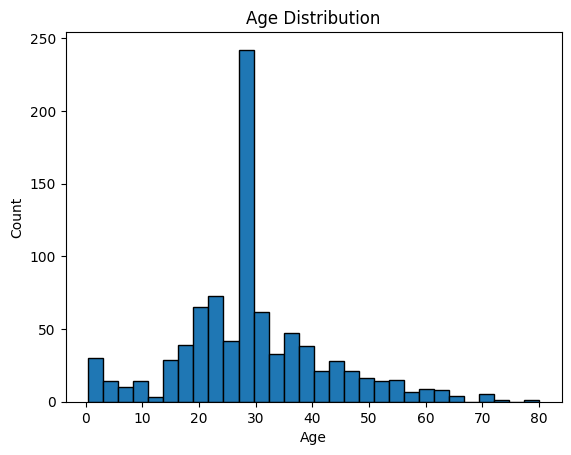

In [21]:
plt.hist(df["Age"] , bins=30 , edgecolor = "black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()



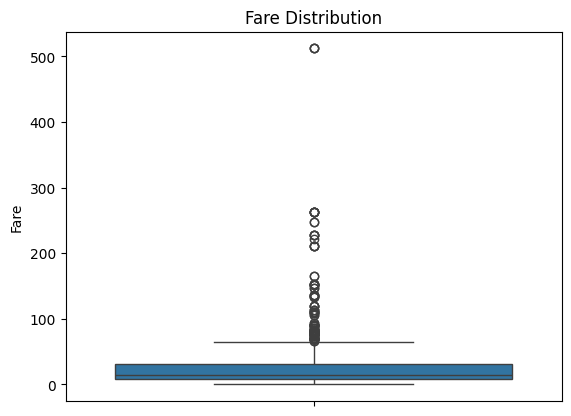

In [22]:
# Boxplot : Fare
sn.boxplot(y = "Fare" , data = df)
plt.title("Fare Distribution")
plt.show()


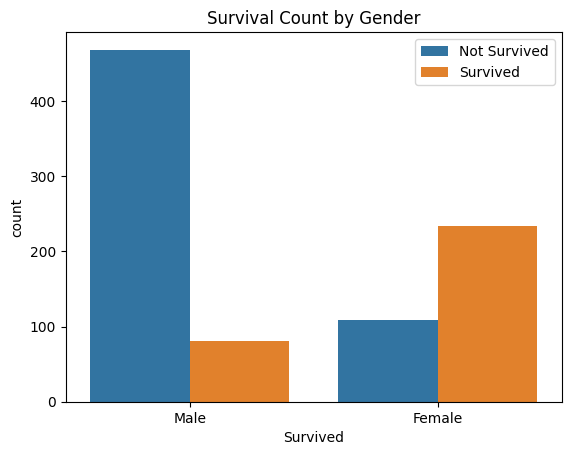

In [24]:
sn.countplot(x = "Survived" , hue = "Sex" , data = df)
plt.title("Survival Count by Gender")
plt.legend( labels=["Not Survived", "Survived"])
plt.xticks([0,1],["Male", "Female"])
plt.show()


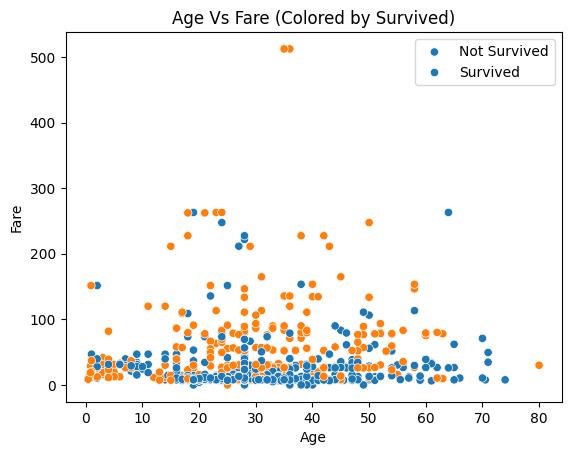

In [26]:
sn.scatterplot(x = "Age" , y = "Fare" , hue = "Survived" , data = df)
plt.title("Age Vs Fare (Colored by Survived)")
plt.legend( labels=["Not Survived", "Survived"])
plt.show()

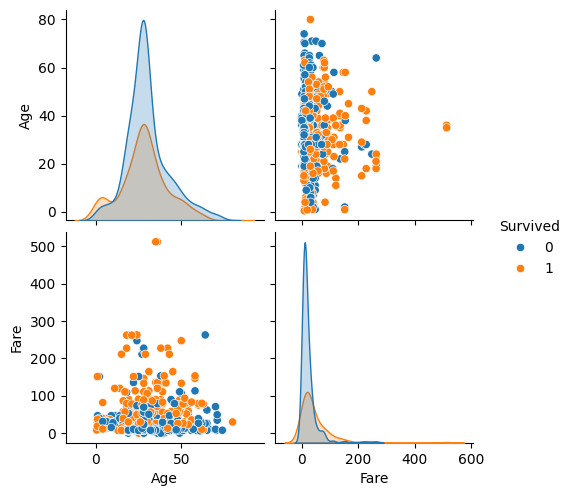

In [30]:
sn.pairplot(df[['Survived', 'Age', 'Fare']], hue='Survived')
plt.show()


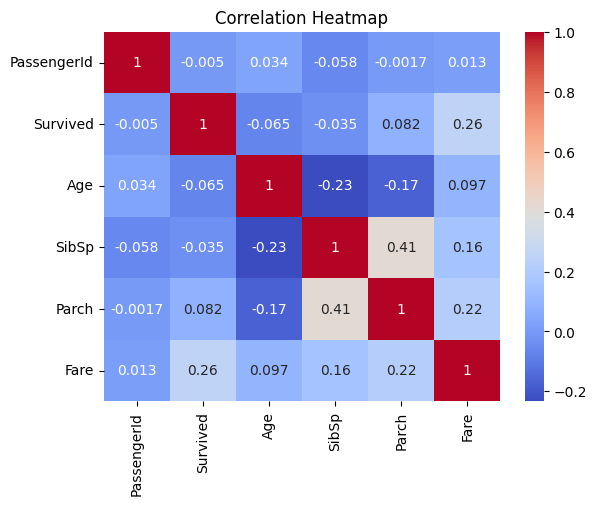

In [31]:
corr = df.corr(numeric_only=True)
sn.heatmap(corr , annot = True , cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
def age_grouping(age):
    if pd.isnull(age):
        return 'Unknown'
    elif age <= 2:
        return 'Baby'
    elif age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Teenager'
    elif age <= 35:
        return 'Young Adult'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['Age'].apply(age_grouping)

In [53]:
# Dictionary ko string keys bana do
class_map = {'1': 'High Class', '2': 'Middle Class', '3': 'Low Class'}
df['class_category'] = df['Pclass'].map(class_map)

In [38]:
df['family_size'] = df['Parch'] + df['SibSp'] + 1


In [39]:
def family_group(size):
    if size == 1:
        return 'Alone'
    elif 2 <= size <= 4:
        return 'Small Family'
    else:
        return 'Large Family'

df['family_group'] = df['family_size'].apply(family_group)

In [54]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,age_group,class_category,family_size,family_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult,Low Class,2,Small Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult,High Class,2,Small Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult,Low Class,1,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult,High Class,2,Small Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult,Low Class,1,Alone


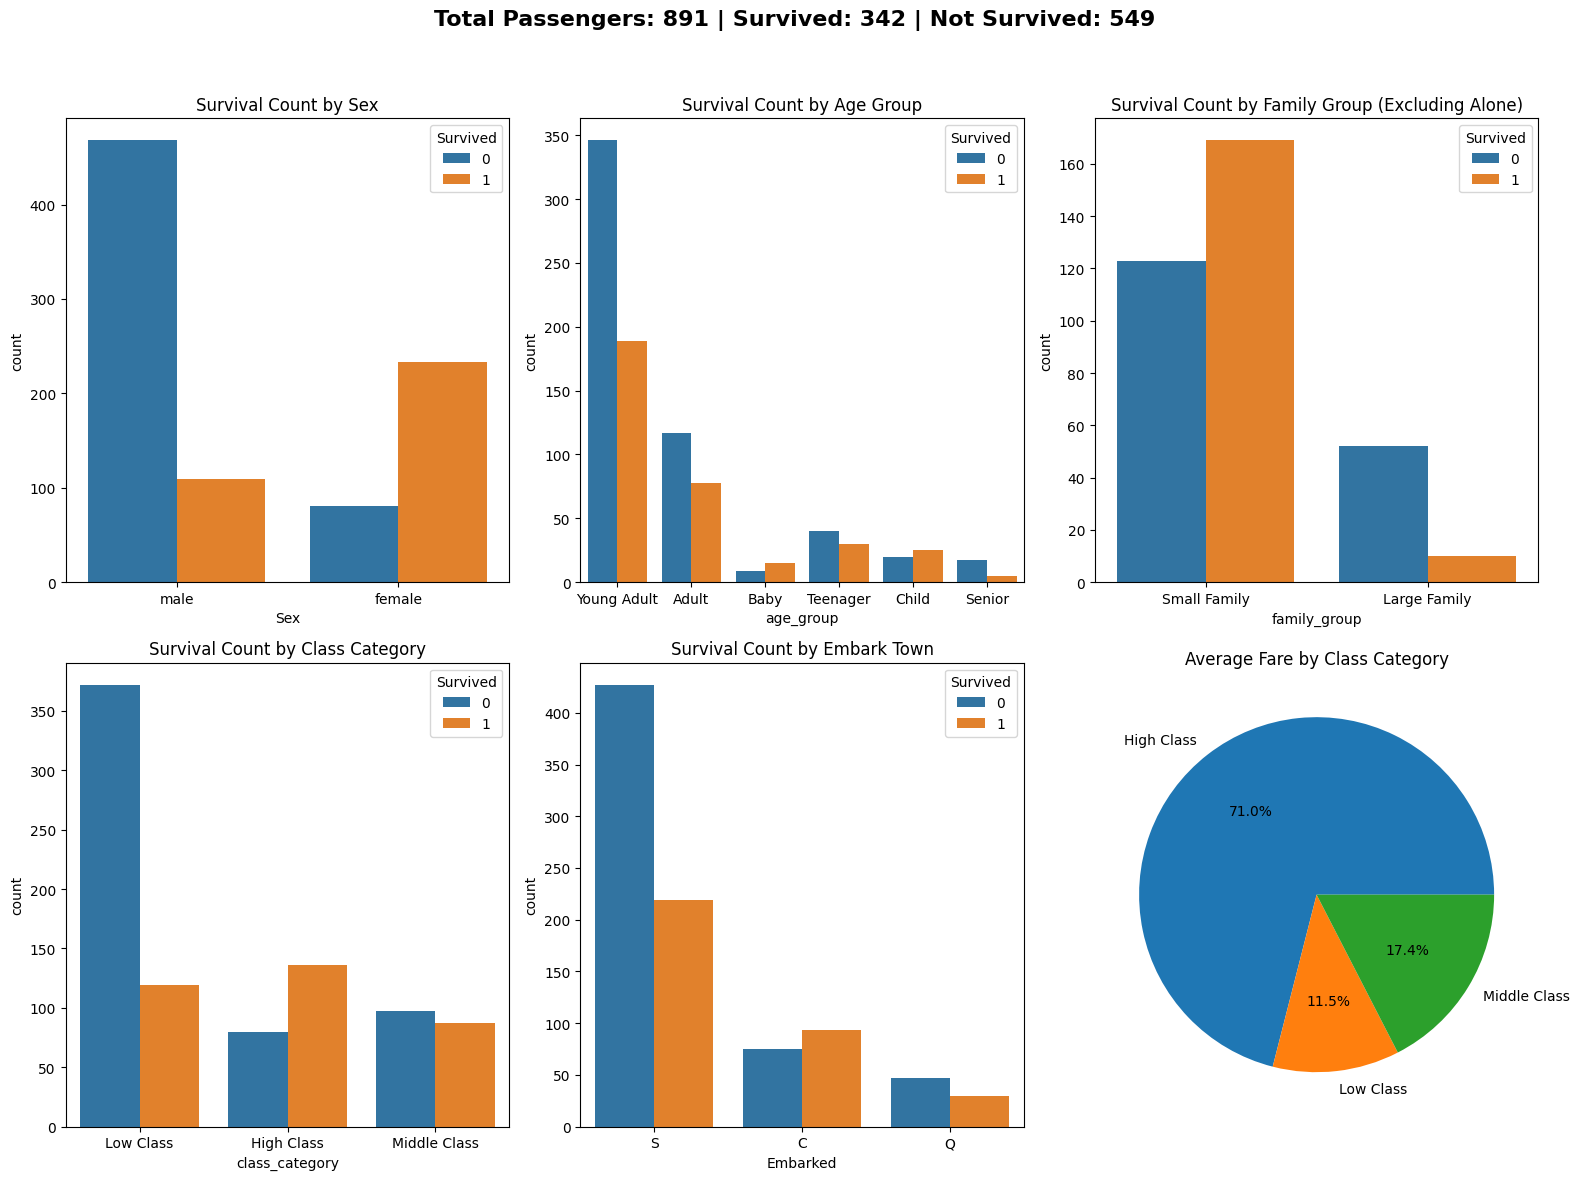

In [55]:
# Multi-Subplot Visualization
plt.figure(figsize=(16, 12))
plt.suptitle(f"Total Passengers: {len(df)} | Survived: {df['Survived'].sum()} | Not Survived: {len(df)-df['Survived'].sum()}",
             fontsize=16, fontweight='bold')

# Plot 1: Survival by Sex
plt.subplot(2, 3, 1)
sn.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Sex')

# Plot 2: Survival by Age Group
plt.subplot(2, 3, 2)
sn.countplot(data=df, x='age_group', hue='Survived')
plt.title('Survival Count by Age Group')

# Plot 3: Survival by Family Group (excluding Alone)
plt.subplot(2, 3, 3)
sn.countplot(data=df[df['family_group'] != 'Alone'], x='family_group', hue='Survived')
plt.title('Survival Count by Family Group (Excluding Alone)')

# Plot 4: Survival by Class Category
plt.subplot(2, 3, 4)
sn.countplot(data=df, x='class_category', hue='Survived')
plt.title('Survival Count by Class Category')

# Plot 5: Survival by Embarked
plt.subplot(2, 3, 5)
sn.countplot(data=df, x='Embarked', hue='Survived')
plt.title('Survival Count by Embark Town')

# Plot 6: Average Fare by Class Category (Pie chart)
plt.subplot(2, 3, 6)
df.groupby('class_category')['Fare'].mean().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title('Average Fare by Class Category')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()